# Binary Data 

In [5]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *
from analyses.helpers import load_results


In [11]:
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt

subset = 'binary_data'
# subset = 'toyMedium'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/pc_gsq/{subset}.pkl', 'rb') as f:
        results_pc_gsq = pickle.load(f)
    

    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
        results_ea_hc = pickle.load(f)
        
    with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
        results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
        results_ea_fes = pickle.load(f)

    with open(f'results/notears/{subset}.pkl', 'rb') as f:
        results_notears = pickle.load(f)

    results_by_label = {
        "PC": results_pc,
        "PC-GSQ": results_pc_gsq,   
        "GES": results_ges,
        "HC": results_hc,
        "EA-HC": results_ea_hc,
        "EA-Base": results_ea_ues,
        "EA-IES": results_ea_ies,
        "EA-FES": results_ea_fes,
        "EA-FG": results_ea_fg,
        # "NOTEARS": results_notears,
        }



mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 12,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 12,            # axis-label size matches body text
    'xtick.labelsize'     : 12,             # tick labels one point smaller
    'ytick.labelsize'     : 12,
    'legend.fontsize'     : 12,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    # 'xtick.minor.size'    : 2,             # half of major — proportional
    # 'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    # 'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    # 'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 600,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})


In [7]:
## violin plot

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# subset = "jpmf_grid"

def violin_grid_2x2(
    df,
    metrics,            # dict: panel_label -> (column_name, y_label)
    alg_order=None,
    filter_dict=None,   # e.g. {"n_nodes": 50, "p_noise": 0.1, "n_xor": 10}
    figsize=(10, 7),
):
    d = df.copy()

    # optional filtering (pick a slice like the paper often does)
    if filter_dict:
        for k, v in filter_dict.items():
            d = d[d[k] == v]

    # keep only needed columns
    needed = ["Algorithm"] + [col for col, _ in metrics.values()]
    d = d[needed].copy()

    # numeric coercion for metrics
    for col, _ in metrics.values():
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna()

    # order
    if alg_order is None:
        alg_order = sorted(d["Algorithm"].unique())

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    for ax, (panel_letter, (col, ylab)) in zip(axes, metrics.items()):
        sns.violinplot(
            data=d,
            x="Algorithm",
            y=col,
            order=alg_order,
            ax=ax,
            inner="box",   # gives that little box/whisker inside
            cut=0,
            linewidth=1,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylab)
        # ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)

        # panel letter like A, B, C, D
        ax.text(-0.12, 1.02, panel_letter, transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom")

    plt.tight_layout()
    return fig, axes



# long_df = long_df[long_df[""]]



In [8]:
## Plots code

def plot_heatmap_from_grid(
    grid,
    title,
    xlabel=None,
    ylabel=None,
    cbar_label=None,
    ax=None,
    vmin=None,
    vmax=None,
    cmap=None,
    norm=None,
    add_colorbar=True,
):
    """Matplotlib heatmap from a pivoted grid DataFrame, with optional shared scaling."""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    data = grid.to_numpy(dtype=float)

    # Decide normalization: explicit norm overrides vmin/vmax
    if norm is None:
        # Only set vmin/vmax if provided; otherwise matplotlib autoscales per-plot
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )
    else:
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            norm=norm,
            cmap=cmap,
        )

    if add_colorbar:
        cb = fig.colorbar(im, ax=ax)
        cb.set_label(cbar_label or "")

    # Tick positions are indices
    x_pos = np.arange(len(grid.columns))
    y_pos = np.arange(len(grid.index))
    ax.set_xticks(x_pos)
    ax.set_yticks(y_pos)

    def _is_numeric_seq(seq):
        try:
            _ = np.asarray(seq, dtype=float)
            return True
        except Exception:
            return False

    cols = list(grid.columns)
    rows = list(grid.index)

    cols_numeric = _is_numeric_seq(cols)
    rows_numeric = _is_numeric_seq(rows)

    if cols_numeric:
        col_vals = np.asarray(cols, dtype=float)
        use_sci = (np.nanmax(np.abs(col_vals)) >= 1e5) or (
            np.nanmin(np.abs(col_vals[np.nonzero(col_vals)])) < 1e-2
            if np.any(col_vals != 0) else False
        )

        if use_sci:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda i, _: f"{col_vals[int(round(i))]:.0e}"
                    if 0 <= int(round(i)) < len(col_vals) else ""
                )
            )
        else:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda i, _: f"{col_vals[int(round(i))]:g}"
                    if 0 <= int(round(i)) < len(col_vals) else ""
                )
            )
    else:
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: str(cols[int(round(i))])
                if 0 <= int(round(i)) < len(cols) else ""
            )
        )

    if rows_numeric:
        row_vals = np.asarray(rows, dtype=float)
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: f"{row_vals[int(round(i))]:g}"
                if 0 <= int(round(i)) < len(row_vals) else ""
            )
        )
    else:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: str(rows[int(round(i))])
                if 0 <= int(round(i)) < len(rows) else ""
            )
        )

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_title(title)

    ax.tick_params(axis="x", labelrotation=45)
    ax.tick_params(axis="both", which="major", labelsize=9)

    return fig, ax, im


def _global_minmax(arrays, robust=False, q=(2, 98), symmetric=False):
    """Compute global vmin/vmax across a list of arrays, ignoring NaNs."""
    vals = []
    for a in arrays:
        if a is None:
            continue
        flat = np.asarray(a, dtype=float).ravel()
        flat = flat[np.isfinite(flat)]
        if flat.size:
            vals.append(flat)
    if not vals:
        return None, None

    allv = np.concatenate(vals)

    if robust:
        lo, hi = np.nanpercentile(allv, [q[0], q[1]])
    else:
        lo, hi = np.nanmin(allv), np.nanmax(allv)

    if symmetric:
        m = np.nanmax(np.abs([lo, hi]))
        return -m, m
    return lo, hi


def plot_final_heatmap(
    long_df,
    plot_metric,
    x_col="samples",
    y_col="p_noise",
    x_label=None,
    y_label=None,
    ncols=None,
    filter=None,
    aggfunc="mean",
    figsize_per_col=(5, 4),
    sharey=True,
    standardize_colors=True,
    robust=False,
    robust_q=(2, 98),
    symmetric=False,
    fixed_vmin=None,
    fixed_vmax=None,
    cmap=None,
    single_colorbar=True,
):
    """
    Plot heatmaps for an arbitrary number of algorithms/results, with standardized colors.

    New args
    --------
    standardize_colors : bool
        If True, all panels share the same vmin/vmax (unless fixed_vmin/vmax given).
    robust : bool
        If True, use percentiles robust_q for vmin/vmax instead of min/max (helps with outliers).
    symmetric : bool
        If True, force symmetric bounds around 0 (useful for signed metrics).
    fixed_vmin, fixed_vmax : float | None
        If provided, overrides computed bounds.
    cmap : str | None
        Optional colormap to pass through.
    single_colorbar : bool
        If True, draw one shared colorbar for the whole figure (recommended when standardized).
    """
    labels = list(long_df["Algorithm"].unique())
    k = len(labels)

    # Choose subplot layout
    if ncols is None:
        ncols = min(4, k)
    nrows = (k + ncols - 1) // ncols

    fig_w = figsize_per_col[0] * ncols
    fig_h = figsize_per_col[1] * nrows
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        constrained_layout=True,
        sharey=sharey
    )

    axes_list = [axes] if k == 1 else list(np.ravel(axes))

    # 1) Build all grids first
    grids_by_label = {}
    grid_arrays = []
    for label in labels:
        df = long_df[long_df["Algorithm"] == label]
        if filter is not None:
            filter_col, filter_val = filter
            df = df[df[filter_col] == filter_val]
        grid = pivot_grid(df, index=y_col, column=x_col, value_col=plot_metric, aggfunc=aggfunc)
        grids_by_label[label] = grid
        grid_arrays.append(grid.to_numpy(dtype=float))

    # 2) Compute shared bounds / norm
    vmin = vmax = None
    norm = None
    if standardize_colors:
        if fixed_vmin is not None or fixed_vmax is not None:
            vmin = fixed_vmin
            vmax = fixed_vmax
        else:
            vmin, vmax = _global_minmax(
                grid_arrays,
                robust=robust,
                q=robust_q,
                symmetric=symmetric
            )
        norm = Normalize(vmin=vmin, vmax=vmax) if (vmin is not None and vmax is not None) else None

    # 3) Plot panels (optionally without per-panel colorbars)
    last_im = None
    for i, label in enumerate(labels):
        ax = axes_list[i]
        grid = grids_by_label[label]

        _, _, im = plot_heatmap_from_grid(
            grid,
            title=f"{label} – {plot_metric}",
            cbar_label=plot_metric,
            ax=ax,
            cmap=cmap,
            norm=norm if standardize_colors else None,
            vmin=None if standardize_colors else fixed_vmin,
            vmax=None if standardize_colors else fixed_vmax,
            add_colorbar=(not single_colorbar) or (not standardize_colors),
        )
        ax.set_xlabel(x_col if x_label is None else x_label)
        ax.set_ylabel(y_col if y_label is None else y_label)
        last_im = im

    # Hide unused axes
    for j in range(k, len(axes_list)):
        axes_list[j].set_visible(False)

    # 4) One shared colorbar
    if standardize_colors and single_colorbar and last_im is not None:
        cb = fig.colorbar(last_im, ax=[ax for ax in axes_list[:k]], shrink=0.9)
        cb.set_label(plot_metric)

    return fig, axes

In [9]:
## new plot code

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize


def pivot_grid(df, index, column, value_col, aggfunc="mean"):
    return df.pivot_table(index=index, columns=column, values=value_col, aggfunc=aggfunc)


def _iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return np.nanpercentile(x, 75) - np.nanpercentile(x, 25)


def plot_heatmap_from_grid(
    grid,
    title,
    xlabel=None,
    ylabel=None,
    cbar_label=None,
    ax=None,
    vmin=None,
    vmax=None,
    cmap=None,
    norm=None,
    add_colorbar=True,
    annot_grid=None,
    fmt="{:.2f}",
    iqr_fmt="{:.2f}",
    text_size=8,
):
    """Matplotlib heatmap from a pivoted grid DataFrame, with optional shared scaling and cell annotations."""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    data = grid.to_numpy(dtype=float)

    if norm is None:
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )
    else:
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            norm=norm,
            cmap=cmap,
        )

    if add_colorbar:
        cb = fig.colorbar(im, ax=ax)
        cb.set_label(cbar_label or "")

    x_pos = np.arange(len(grid.columns))
    y_pos = np.arange(len(grid.index))
    ax.set_xticks(x_pos)
    ax.set_yticks(y_pos)

    def _is_numeric_seq(seq):
        try:
            _ = np.asarray(seq, dtype=float)
            return True
        except Exception:
            return False

    cols = list(grid.columns)
    rows = list(grid.index)

    cols_numeric = _is_numeric_seq(cols)
    rows_numeric = _is_numeric_seq(rows)

    if cols_numeric:
        col_vals = np.asarray(cols, dtype=float)
        use_sci = (np.nanmax(np.abs(col_vals)) >= 1e5) or (
            np.nanmin(np.abs(col_vals[np.nonzero(col_vals)])) < 1e-2
            if np.any(col_vals != 0) else False
        )

        if use_sci:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda i, _: f"{col_vals[int(round(i))]:.0e}"
                    if 0 <= int(round(i)) < len(col_vals) else ""
                )
            )
        else:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda i, _: f"{col_vals[int(round(i))]:g}"
                    if 0 <= int(round(i)) < len(col_vals) else ""
                )
            )
    else:
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: str(cols[int(round(i))])
                if 0 <= int(round(i)) < len(cols) else ""
            )
        )

    if rows_numeric:
        row_vals = np.asarray(rows, dtype=float)
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: f"{row_vals[int(round(i))]:g}"
                if 0 <= int(round(i)) < len(row_vals) else ""
            )
        )
    else:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: str(rows[int(round(i))])
                if 0 <= int(round(i)) < len(rows) else ""
            )
        )

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_title(title)

    ax.tick_params(axis="x", labelrotation=45)
    ax.tick_params(axis="both", which="major", labelsize=9)

    # ---- annotations: mean and IQR ----
    if annot_grid is not None:
        annot_vals = annot_grid.to_numpy(dtype=float)

        finite_vals = data[np.isfinite(data)]
        midpoint = np.nanmean(finite_vals) if finite_vals.size else 0.0

        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                mean_val = data[r, c]
                iqr_val = annot_vals[r, c]

                if not np.isfinite(mean_val):
                    continue

                text = fmt.format(mean_val)
                if np.isfinite(iqr_val):
                    text += "\n[" + iqr_fmt.format(iqr_val) + "]"

                color = "white" if mean_val < midpoint else "black"
                ax.text(
                    c, r, text,
                    ha="center", va="center",
                    fontsize=text_size,
                    color=color,
                )

    return fig, ax, im


def _global_minmax(arrays, robust=False, q=(2, 98), symmetric=False):
    vals = []
    for a in arrays:
        if a is None:
            continue
        flat = np.asarray(a, dtype=float).ravel()
        flat = flat[np.isfinite(flat)]
        if flat.size:
            vals.append(flat)
    if not vals:
        return None, None

    allv = np.concatenate(vals)

    if robust:
        lo, hi = np.nanpercentile(allv, [q[0], q[1]])
    else:
        lo, hi = np.nanmin(allv), np.nanmax(allv)

    if symmetric:
        m = np.nanmax(np.abs([lo, hi]))
        return -m, m
    return lo, hi


def plot_final_heatmap(
    long_df,
    plot_metric,
    x_col="samples",
    y_col="p_noise",
    x_label=None,
    y_label=None,
    ncols=None,
    filter=None,
    aggfunc="mean",
    figsize_per_col=(5, 4),
    sharey=True,
    standardize_colors=True,
    robust=False,
    robust_q=(2, 98),
    symmetric=False,
    fixed_vmin=None,
    fixed_vmax=None,
    cmap=None,
    single_colorbar=True,
    show_iqr=True,
    mean_fmt="{:.2f}",
    iqr_fmt="{:.2f}",
    text_size=8,
):
    """
    Plot heatmaps for an arbitrary number of algorithms/results, with standardized colors.
    Each cell can be annotated with mean and IQR.
    """
    labels = list(long_df["Algorithm"].unique())
    k = len(labels)

    if ncols is None:
        ncols = min(4, k)
    nrows = (k + ncols - 1) // ncols

    fig_w = figsize_per_col[0] * ncols
    fig_h = figsize_per_col[1] * nrows
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        constrained_layout=True,
        sharey=sharey
    )

    axes_list = [axes] if k == 1 else list(np.ravel(axes))

    grids_by_label = {}
    iqr_grids_by_label = {}
    grid_arrays = []

    for label in labels:
        df = long_df[long_df["Algorithm"] == label]
        if filter is not None:
            filter_col, filter_val = filter
            df = df[df[filter_col] == filter_val]

        mean_grid = pivot_grid(df, index=y_col, column=x_col, value_col=plot_metric, aggfunc=aggfunc)
        grids_by_label[label] = mean_grid
        grid_arrays.append(mean_grid.to_numpy(dtype=float))

        if show_iqr:
            iqr_grid = pivot_grid(df, index=y_col, column=x_col, value_col=plot_metric, aggfunc=_iqr)
            iqr_grids_by_label[label] = iqr_grid
        else:
            iqr_grids_by_label[label] = None

    vmin = vmax = None
    norm = None
    if standardize_colors:
        if fixed_vmin is not None or fixed_vmax is not None:
            vmin = fixed_vmin
            vmax = fixed_vmax
        else:
            vmin, vmax = _global_minmax(
                grid_arrays,
                robust=robust,
                q=robust_q,
                symmetric=symmetric
            )
        norm = Normalize(vmin=vmin, vmax=vmax) if (vmin is not None and vmax is not None) else None

    last_im = None
    for i, label in enumerate(labels):
        ax = axes_list[i]
        grid = grids_by_label[label]
        iqr_grid = iqr_grids_by_label[label]

        _, _, im = plot_heatmap_from_grid(
            grid,
            title=f"{label} – {plot_metric}",
            cbar_label=plot_metric,
            ax=ax,
            cmap=cmap,
            norm=norm if standardize_colors else None,
            vmin=None if standardize_colors else fixed_vmin,
            vmax=None if standardize_colors else fixed_vmax,
            add_colorbar=(not single_colorbar) or (not standardize_colors),
            annot_grid=iqr_grid,
            fmt=mean_fmt,
            iqr_fmt=iqr_fmt,
            text_size=text_size,
        )
        ax.set_xlabel(x_col if x_label is None else x_label)
        ax.set_ylabel(y_col if y_label is None else y_label)
        last_im = im

    for j in range(k, len(axes_list)):
        axes_list[j].set_visible(False)

    if standardize_colors and single_colorbar and last_im is not None:
        cb = fig.colorbar(last_im, ax=[ax for ax in axes_list[:k]], shrink=0.9)
        cb.set_label(plot_metric)

    return fig, axes

## Collider 

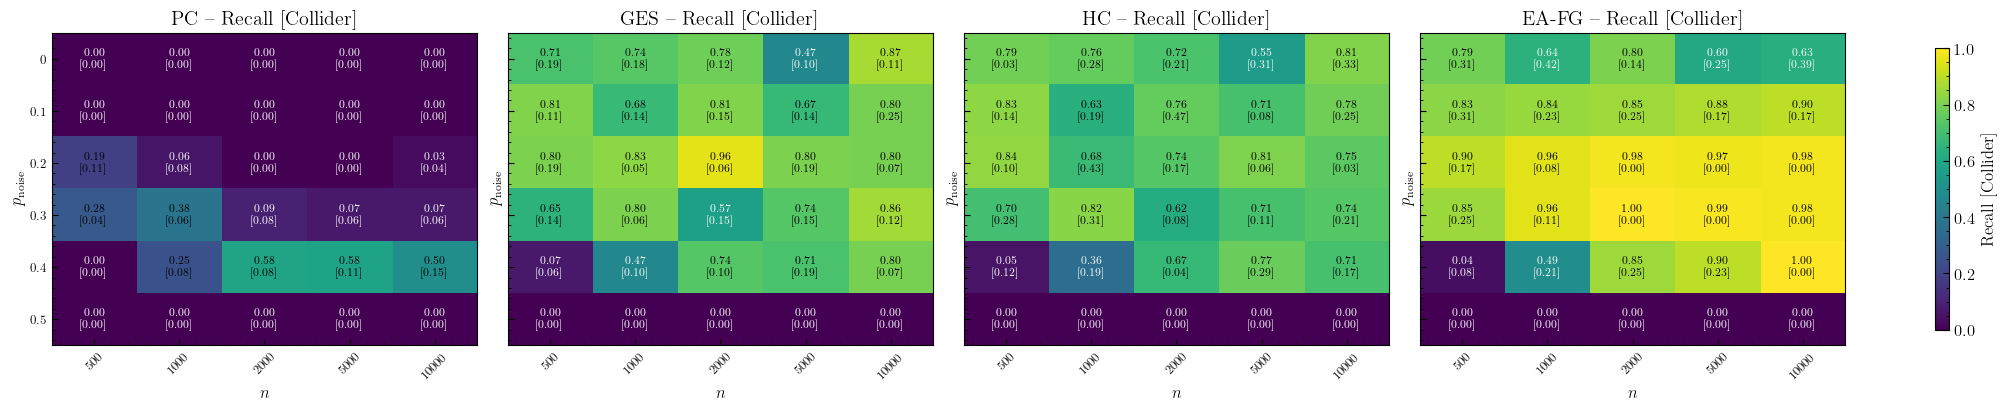

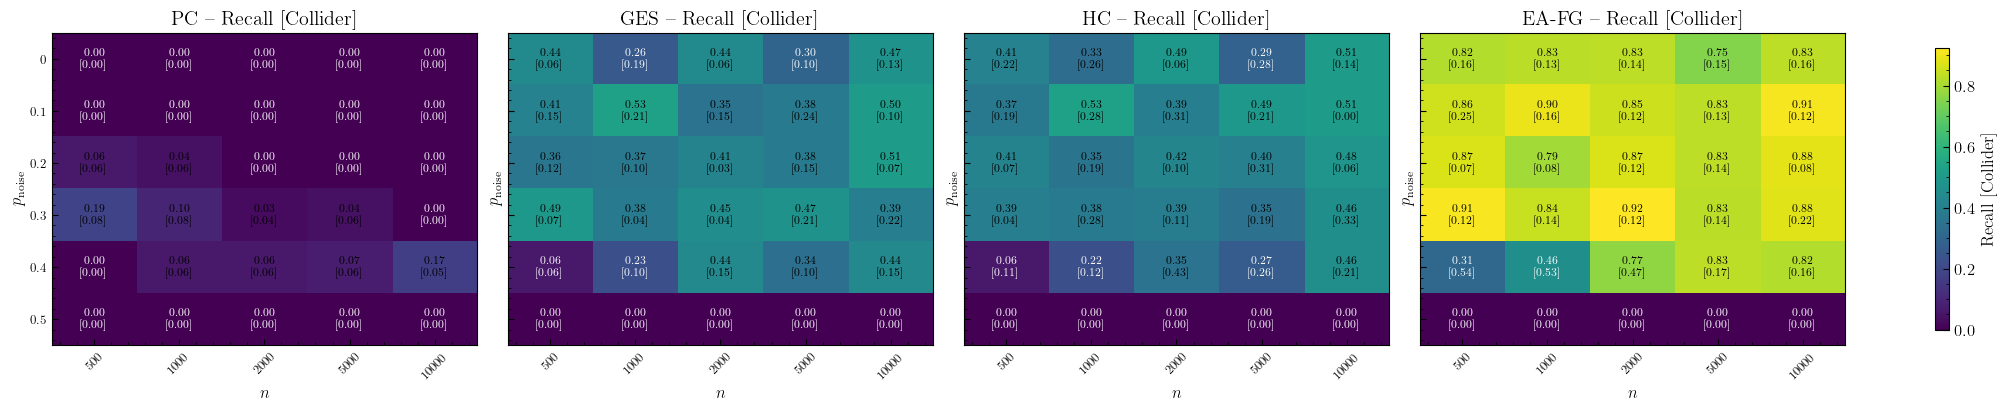

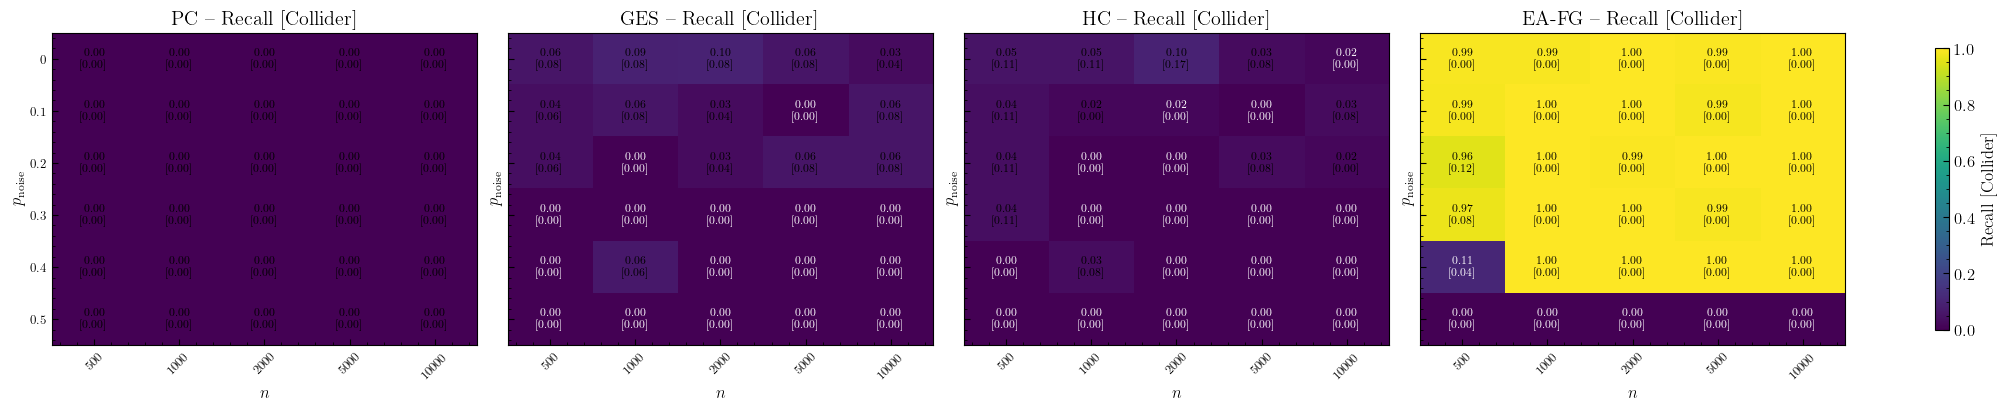

In [ ]:
load_results(subset)
# long_df = build_long_metrics(results_by_label)
plot_results = {k: results_by_label[k] for k in ["PC", "GES", "HC", "EA-FG"]}
sub_df = build_long_metrics(plot_results)

# sub_df = sub_df[sub_df["total_vars"] == 30]

metric = "Recall [Collider]"
x_col = "samples"
y_col = "p_noise"

filters = [("p_syn", 0), ("p_syn", 0.5), ("p_syn", 1)]
i = 1
for filter in filters:
    filter_col, filter_val = filter
    fig, axes = plot_final_heatmap(
        sub_df,
        # mapping=mapping,
        ncols=4,
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        show_iqr=True,
        filter=(filter_col, filter_val),
        y_col=y_col,
        x_label=f"$n$",
        y_label=r"$p_{\mathrm{noise}}$",
    )    
    plt.savefig(f"Figures/binaryData/Fig1_{i}.png", bbox_inches='tight')
    i += 1
   

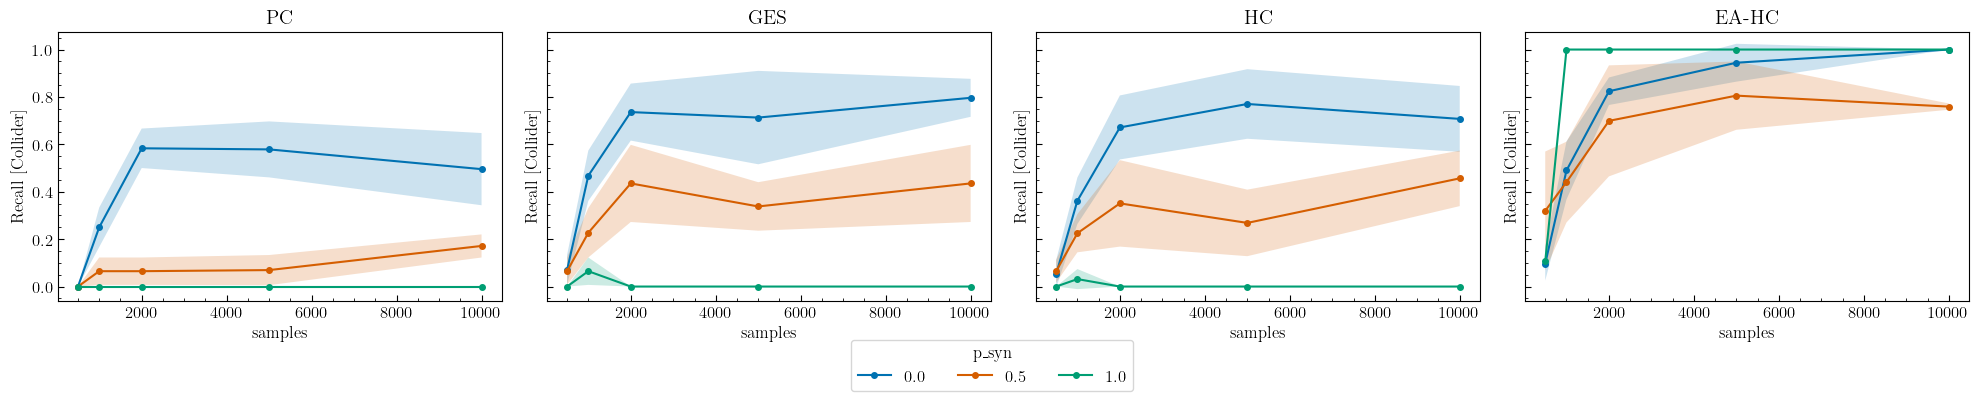

In [23]:
plot_results = {k: results_by_label[k] for k in ["PC", "GES", "HC","EA-HC"]}
sub_df = build_long_metrics(plot_results)

# sub_df = sub_df[sub_df["p_syn"] == 0.5]
sub_df = sub_df[sub_df["total_vars"] == 30]
sub_df = sub_df[sub_df["p_noise"] == 0.4]

fig, ax = plot_final_metric_vs_x(
    sub_df,
    metric_col="Recall [Collider]",
    x_col="samples",
    by="p_syn",
    # x_label=f"$n$",
    # y_label=metric,
    # alg_order=["PC", "GES", "HC", "EA-FG"],
    # figsize=(10, 7)
)

plt.savefig(f"Figures/binaryData/Fig2.png", bbox_inches='tight')
# fig
# ax


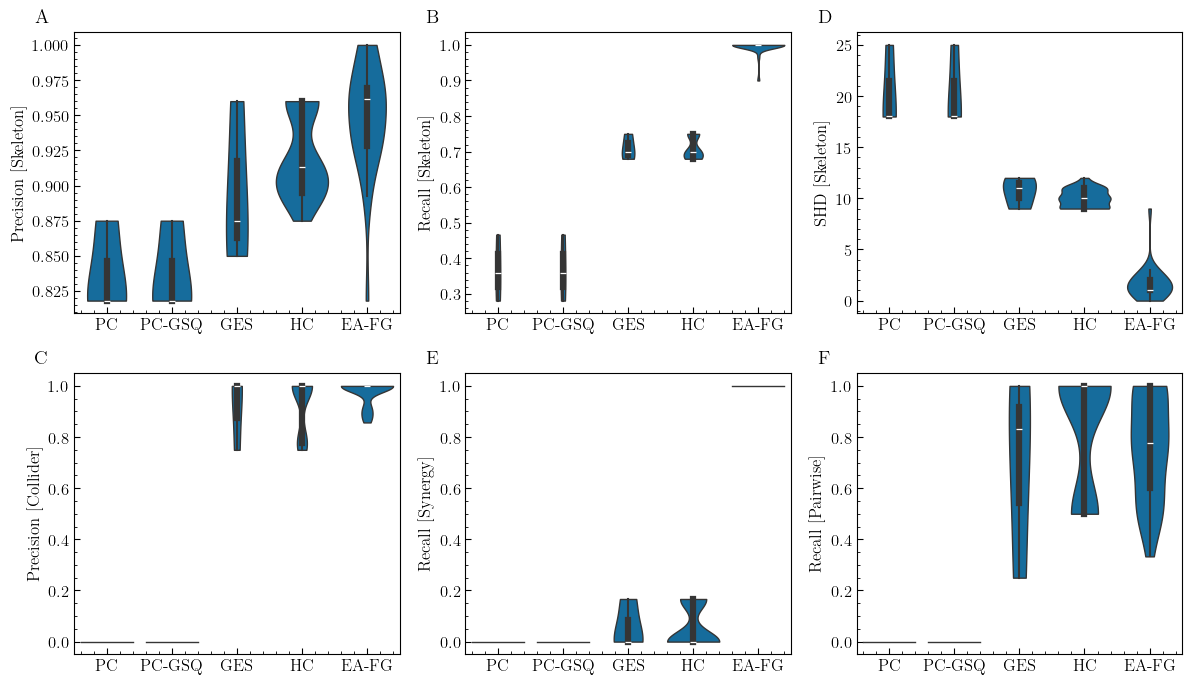

In [24]:
plot_results = {k: results_by_label[k] for k in ["PC", "PC-GSQ", "GES", "HC", "EA-FG"]}
sub_df = build_long_metrics(plot_results)

metrics = {
    "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
    "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "C": ("Precision [Collider]", "Precision [Collider]"),
    "E": ("Recall [Synergy]", "Recall [Synergy]"),
    "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
}

alg_order = ["PC", "PC-GSQ", "GES", "HC", "EA-FG"] 

# Example slice (optional):
filter_dict = {"p_syn": 0.5, "p_noise": 0.3, "samples": 10_000, "total_vars": 30}
# filter_dict = None

fig, axes = violin_grid_2x2(
    sub_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(12, 7),
)

plt.savefig(
    f"Figures/binaryData/Fig3.png",
    dpi=800,
)


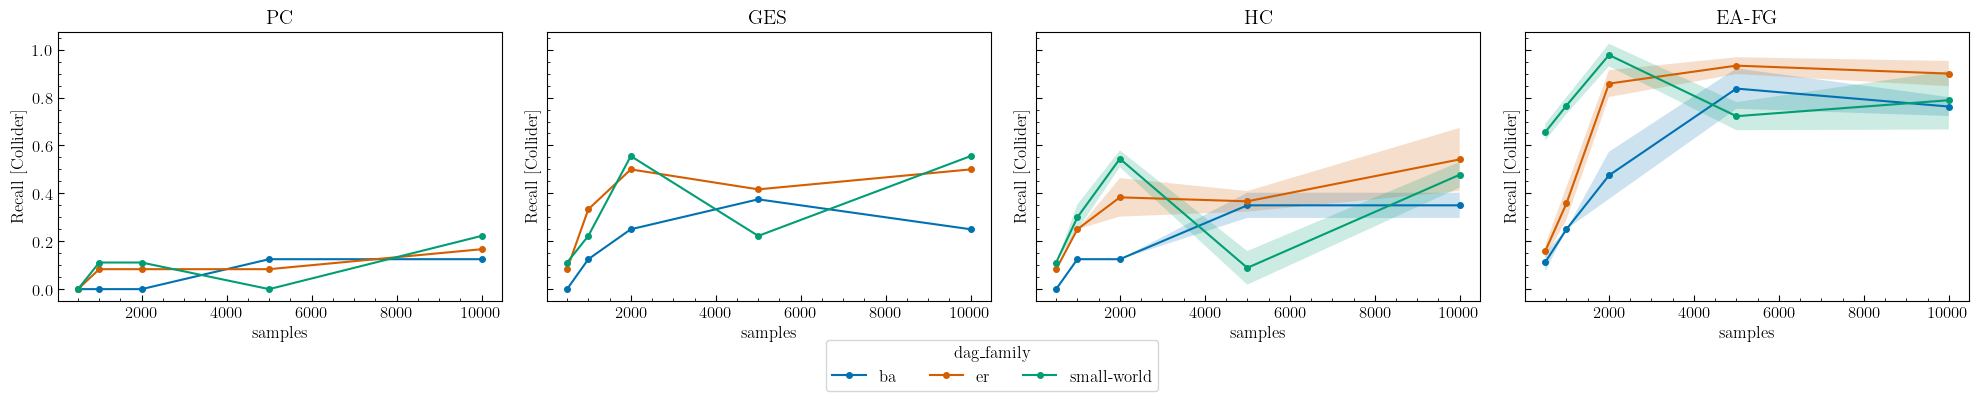

In [25]:
plot_results = {k: results_by_label[k] for k in ["PC", "GES", "HC", "EA-FG"]}
sub_df = build_long_metrics(plot_results)

# sub_df = sub_df[sub_df["p_syn"] == 0.5]
sub_df = sub_df[sub_df["total_vars"] == 30]
sub_df = sub_df[sub_df["p_noise"] == 0.4]
sub_df = sub_df[sub_df["p_syn"] == 0.5]



fig, ax = plot_final_metric_vs_x(
    sub_df,
    metric_col="Recall [Collider]",
    x_col="samples",
    by="dag_family",
    # x_label=f"$n$",
    # y_label=metric,
    # alg_order=["PC", "GES", "HC", "EA-FG"],
    # figsize=(10, 7)
)

plt.savefig(f"Figures/binaryData/Fig4.png", bbox_inches='tight')
# fig
# ax


In [22]:
# long_df = long_df[long_df["Total (SC)"] >= 1 & (long_df["Total (PW)"] >= 1)]